# Autoencoder

This notebook trains one dense autoencoder per entry (every chosen device plus the pooled case) on benign training traffic only, and scores every test row by its reconstruction error.

The reconstruction-error score follows the same "higher = more anomalous" convention as the K-Means and DBSCAN scores from the clustering notebook, with predictions built the same way: a row is flagged if its score exceeds a threshold set from benign validation data. This lets the evaluation notebook treat all three models identically.

In [1]:
# Standard library
import os
import time
from pathlib import Path

# Move into the repository root so config.py and every relative path inside it resolve correctly
if not Path("config.py").exists():
    os.chdir("..")

# Quiet TensorFlow's oneDNN and CPU-instruction notices
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

# Local
import config

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

## Seed every random step, including TensorFlow

`keras.utils.set_random_seed` seeds Python's `random` module, NumPy, and TensorFlow together from a single call.

This makes the random number generators reproducible, but it does not force deterministic CPU kernels. Some TensorFlow operations are order-dependent, so loss values may still differ in the last decimal place between runs. The architecture, the chosen thresholds, and the arrays saved to disk are unaffected. Op determinism is not enabled here.

In [2]:
# Seed Python, NumPy, and TensorFlow together
keras.utils.set_random_seed(config.RANDOM_SEED)

## Load the autoencoder arrays

Every chosen device, plus the pooled case, is loaded from the standardised, correlation-pruned autoencoder arrays that the preprocessing notebook wrote to `data/processed/`. Each entry's input width is printed below, since it drives the architecture built further down.

In [3]:
# Load the autoencoder arrays for every chosen device and the pooled case
entries = config.CHOSEN_DEVICES + ["_pooled"]
entry_arrays = {}
for entry in entries:
    entry_arrays[entry] = config.load_arrays(entry, "X_train_autoencoder", "X_val_autoencoder", "X_test_autoencoder")
    train_shape = entry_arrays[entry]["X_train_autoencoder"].shape
    val_shape = entry_arrays[entry]["X_val_autoencoder"].shape
    test_shape = entry_arrays[entry]["X_test_autoencoder"].shape
    print(f"{entry}: Train={train_shape}, Validate={val_shape}, Test={test_shape}")

Danmini_Doorbell: Train=(28276, 52), Validate=(6059, 52), Test=(46060, 52)
Philips_B120N10_Baby_Monitor: Train=(115598, 52), Validate=(24771, 52), Test=(64772, 52)
Provision_PT_838_Security_Camera: Train=(65796, 41), Validate=(14099, 41), Test=(54100, 41)
_pooled: Train=(84828, 53), Validate=(18177, 53), Test=(164932, 53)


## Build the dense autoencoder architecture

For a given input width, the encoder shrinks it step by step through `config.AUTOENCODER_LAYER_RATIOS` (75%, 50%, 33%, then 25% of the input width, each rounded down and floored at 2 units), and the decoder mirrors those widths back out, stopping one layer short of repeating the bottleneck.

Every hidden layer uses a ReLU activation. The output layer is linear instead of bounded, because the input arrays are standardised and routinely negative. Hence, the network must be able to reproduce a negative value exactly. A bounded activation there would clip the reconstruction and bias the anomaly score.

The model is compiled with the Adam optimiser and mean squared error loss.

In [4]:
# Build a dense autoencoder: encoder shrinks by ratio, decoder mirrors back out
def build_autoencoder(input_width, ratios):
    encoder_widths = [max(2, int(input_width * ratio)) for ratio in ratios]
    decoder_widths = encoder_widths[-2::-1]

    inputs = keras.Input(shape=(input_width,))
    hidden_layer = inputs
    for width in encoder_widths:
        hidden_layer = keras.layers.Dense(width, activation="relu")(hidden_layer)
    for width in decoder_widths:
        hidden_layer = keras.layers.Dense(width, activation="relu")(hidden_layer)
    outputs = keras.layers.Dense(input_width, activation="linear")(hidden_layer)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

## Train one autoencoder per entry

Each entry gets its own model, since both the input width and the underlying data differ by entry. Input and target are the same benign training rows. The network is trained to rebuild what it is shown, not to predict a separate target. Training stops once `config.AUTOENCODER_EARLY_STOPPING_PATIENCE` epochs have passed with no improvement in validation loss, restoring the weights from the best epoch. `config.AUTOENCODER_EPOCHS` is only a safety ceiling.

The random seed is set again at the top of every iteration and not only once above. Weight initialisation draws from the global random state, so without reseeding per entry, each entry's model will depend on how many models were fitted before it. Re-running this cell alone will produce a different model and a different threshold each time. Hence, reseeding per entry is done instead as it makes every entry reproducible on its own.

In [5]:
# Build and fit one autoencoder per entry, reseeding first so each entry is independently reproducible
autoencoder_by_entry = {}
for entry, arrays in entry_arrays.items():
    keras.utils.set_random_seed(config.RANDOM_SEED)

    input_width = arrays["X_train_autoencoder"].shape[1]
    model = build_autoencoder(input_width, config.AUTOENCODER_LAYER_RATIOS)

    start_time = time.perf_counter()
    history = model.fit(
        arrays["X_train_autoencoder"], arrays["X_train_autoencoder"],
        validation_data=(arrays["X_val_autoencoder"], arrays["X_val_autoencoder"]),
        epochs=config.AUTOENCODER_EPOCHS,
        batch_size=config.AUTOENCODER_BATCH_SIZE,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=config.AUTOENCODER_EARLY_STOPPING_PATIENCE, restore_best_weights=True)],
        verbose=2,
    )
    training_seconds = time.perf_counter() - start_time

    autoencoder_by_entry[entry] = {"model": model, "history": history, "input_width": input_width, "training_seconds": training_seconds}
    layer_widths = [layer.units for layer in model.layers if isinstance(layer, keras.layers.Dense)]
    print(f"{entry}: Input width={input_width}, Layer widths={layer_widths}, Training seconds={training_seconds:.1f}")

Epoch 1/100
221/221 - 2s - 7ms/step - loss: 0.7496 - val_loss: 0.5449
Epoch 2/100
221/221 - 0s - 1ms/step - loss: 0.5115 - val_loss: 0.3983
Epoch 3/100
221/221 - 0s - 1ms/step - loss: 0.4344 - val_loss: 0.3242
Epoch 4/100
221/221 - 0s - 1ms/step - loss: 0.3727 - val_loss: 0.2707
Epoch 5/100
221/221 - 0s - 1ms/step - loss: 0.3252 - val_loss: 0.2305
Epoch 6/100
221/221 - 0s - 1ms/step - loss: 0.2989 - val_loss: 0.2059
Epoch 7/100
221/221 - 0s - 1ms/step - loss: 0.2651 - val_loss: 0.1954
Epoch 8/100
221/221 - 0s - 1ms/step - loss: 0.2435 - val_loss: 0.1862
Epoch 9/100
221/221 - 0s - 1ms/step - loss: 0.2399 - val_loss: 0.1794
Epoch 10/100
221/221 - 1s - 4ms/step - loss: 0.2094 - val_loss: 0.1759
Epoch 11/100
221/221 - 1s - 5ms/step - loss: 0.2119 - val_loss: 0.1724
Epoch 12/100
221/221 - 1s - 5ms/step - loss: 0.1971 - val_loss: 0.1621
Epoch 13/100
221/221 - 1s - 3ms/step - loss: 0.1854 - val_loss: 0.1569
Epoch 14/100
221/221 - 2s - 7ms/step - loss: 0.1712 - val_loss: 0.1557
Epoch 15/100
22

## Plot each entry's training curve

The training and validation loss are plotted against epoch for every entry, so overfitting or underfitting can be checked by eye before anything downstream relies on the fitted model. This plot is saved for every entry, including the pooled case.

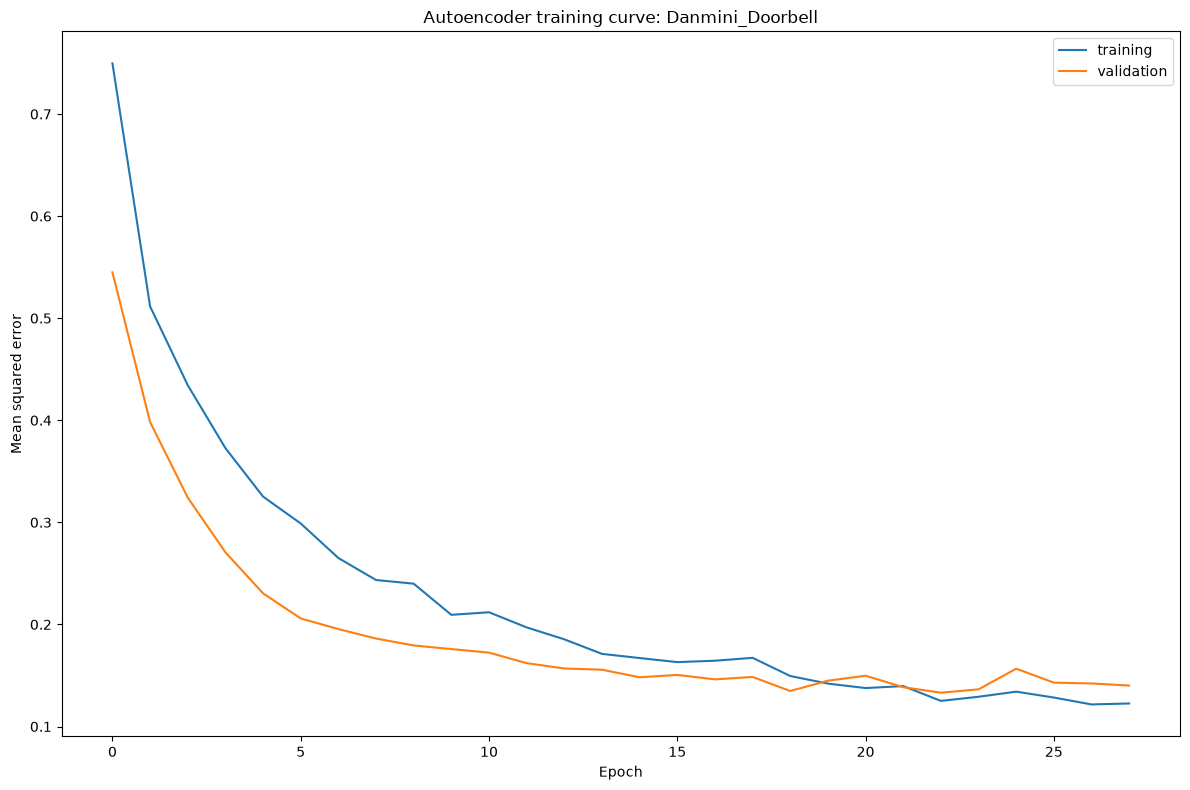

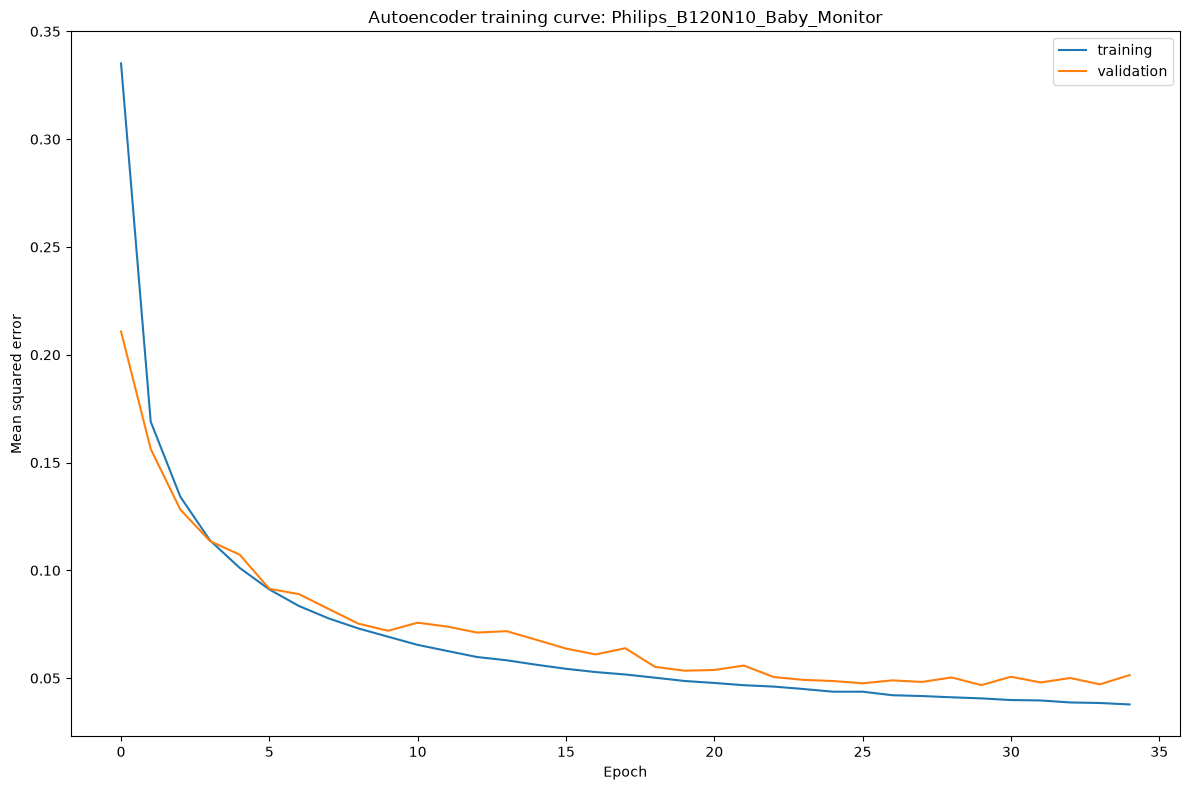

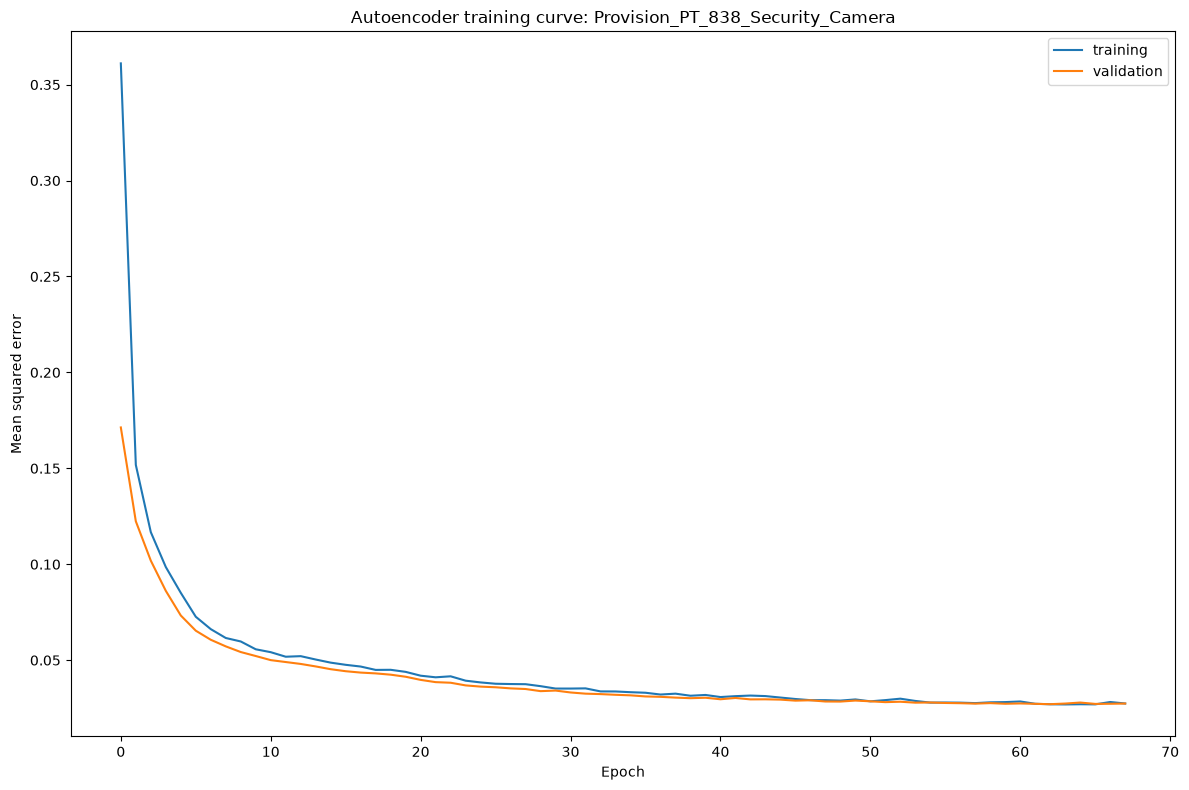

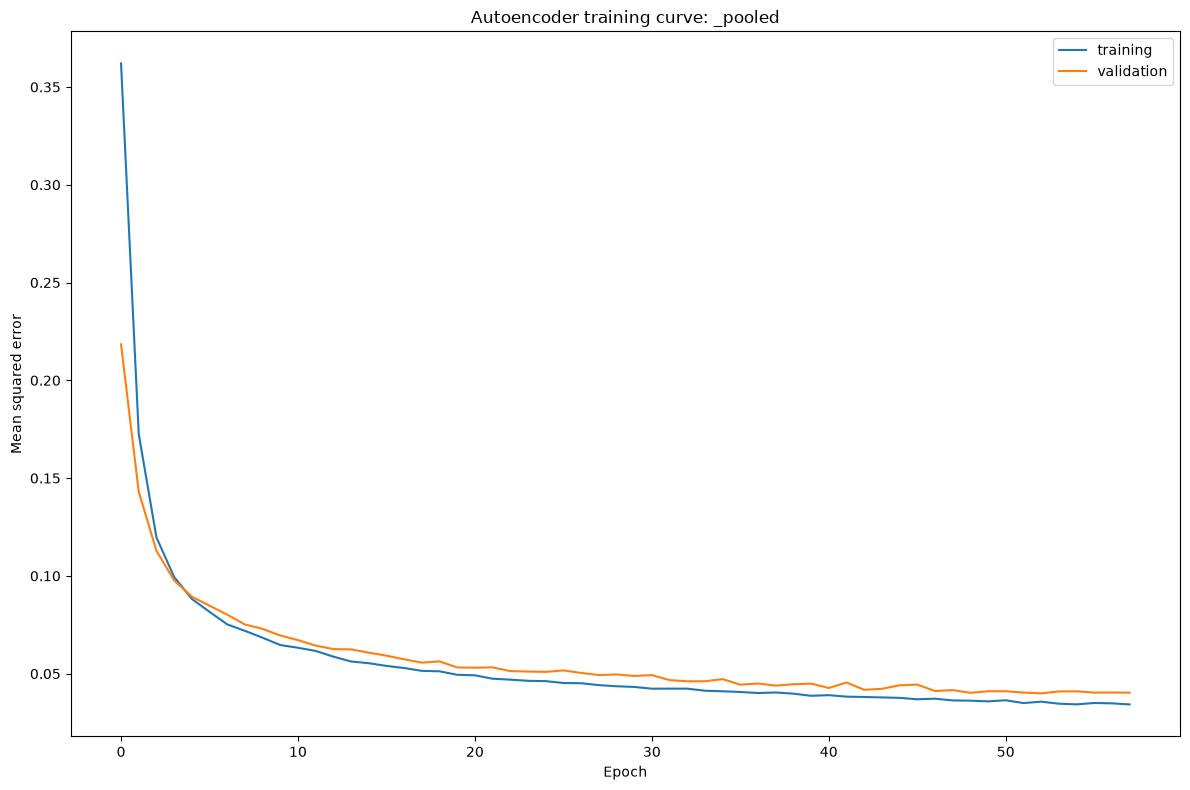

In [6]:
# Plot the training and validation loss against epoch for every entry
for entry, result in autoencoder_by_entry.items():
    history = result["history"].history

    figure, axis = plt.subplots(figsize=(12, 8))
    axis.plot(history["loss"], label="training")
    axis.plot(history["val_loss"], label="validation")
    axis.set_title(f"Autoencoder training curve: {entry}")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Mean squared error")
    axis.legend()
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"autoencoder_training_curve_{entry}.png")
    plt.show()
    plt.close(figure)

## Compute reconstruction error

The anomaly score for a row is its reconstruction error: the mean squared error between the row and the model's rebuild of it, averaged across that entry's columns so the score is on a comparable scale regardless of how many columns survived pruning for that entry. Prediction is passed an explicit batch size, since the default is far smaller than the pooled test set and will otherwise slow scoring for no benefit.

In [7]:
# Per-row mean squared error between a batch of rows and the model's rebuild of them
def reconstruction_error(model, X, batch_size):
    reconstructed = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X - reconstructed), axis=1)

## Threshold sensitivity table

For every entry, the reconstruction error is computed once on the benign validation rows and kept for reuse below. For Z = 1, 2, and 3, plus whatever `config.AUTOENCODER_THRESHOLD_Z` is currently set to, the alarm threshold `mean + Z * std` of that validation error is computed, along with the share of validation rows it will flag.

Only benign validation error is used here.

In [8]:
# Threshold and validation-flagged fraction for a spread of Z values, per entry
z_values = sorted({1, 2, 3} | {config.AUTOENCODER_THRESHOLD_Z})

sensitivity_rows = []
for entry, result in autoencoder_by_entry.items():
    val_error = reconstruction_error(result["model"], entry_arrays[entry]["X_val_autoencoder"], config.AUTOENCODER_SCORING_BATCH_SIZE)
    result["val_error"] = val_error

    threshold_by_z = {}
    val_flagged_by_z = {}
    for z in z_values:
        threshold = val_error.mean() + z * val_error.std()
        threshold_by_z[z] = threshold
        val_flagged_by_z[z] = (val_error > threshold).mean()

    result["threshold_by_z"] = threshold_by_z
    result["val_flagged_by_z"] = val_flagged_by_z
    for z in z_values:
        sensitivity_rows.append({"entry": entry, "z": z, "threshold": threshold_by_z[z], "validation_flagged_fraction": val_flagged_by_z[z]})

pd.DataFrame(sensitivity_rows)

,entry,z,threshold,validation_flagged_fraction
0,Danmini_Doorbell,1,2.984578,0.003961
1,Danmini_Doorbell,2,5.836016,0.003631
2,Danmini_Doorbell,3,8.687455,0.002971
3,Philips_B120N10_Baby_Monitor,1,0.319930,0.028743
4,Philips_B120N10_Baby_Monitor,2,0.593081,0.017198
5,Philips_B120N10_Baby_Monitor,3,0.866232,0.011626
6,Provision_PT_838_Security_Camera,1,0.154706,0.011490
7,Provision_PT_838_Security_Camera,2,0.282341,0.005390
8,Provision_PT_838_Security_Camera,3,0.409976,0.003688
9,_pooled,1,0.408404,0.012928


## Score test rows and flag anomalies

The threshold applied to the test set is read straight from the row for `config.AUTOENCODER_THRESHOLD_Z` computed above. This ensures that the sensitivity table and the operating threshold can never drift apart. A test row is predicted as an attack if its reconstruction error exceeds that threshold.

In [9]:
# Score every entry's test rows against the threshold chosen for config.AUTOENCODER_THRESHOLD_Z
for entry, result in autoencoder_by_entry.items():
    threshold = result["threshold_by_z"][config.AUTOENCODER_THRESHOLD_Z]

    test_error = reconstruction_error(result["model"], entry_arrays[entry]["X_test_autoencoder"], config.AUTOENCODER_SCORING_BATCH_SIZE)
    test_pred = (test_error > threshold).astype(int)

    result["threshold"] = threshold
    result["test_error"] = test_error
    result["test_pred"] = test_pred
    print(f"{entry}: Threshold={threshold:.3f}, Test flagged={test_pred.mean():.1%}")

Danmini_Doorbell: Threshold=8.687, Test flagged=69.5%
Philips_B120N10_Baby_Monitor: Threshold=0.866, Test flagged=62.2%
Provision_PT_838_Security_Camera: Threshold=0.410, Test flagged=59.2%
_pooled: Threshold=1.145, Test flagged=58.4%


## Save each entry's trained model, scores, and predictions

The trained Keras model, and the test reconstruction error and prediction arrays built above are written to disk for every entry.

In [10]:
# Save every entry's trained model and test scores and predictions
for entry, result in autoencoder_by_entry.items():
    (Path(config.MODEL_DIRECTORY) / entry).mkdir(parents=True, exist_ok=True)
    result["model"].save(Path(config.MODEL_DIRECTORY) / entry / "autoencoder.keras")
    config.save_arrays(entry, autoencoder_score=result["test_error"], autoencoder_pred=result["test_pred"])

## Verify the saved outputs

Everything just written is reloaded from disk and checked. Every array's row count must match that entry's test row count, and the prediction array must contain only 0s and 1s. Each entry's saved model is also reloaded and checked against the in-memory model it was saved from.

Their reconstruction error must agree on a sample of validation rows, since file existence alone does not catch a corrupt save. A summary table is built from the reloaded arrays and the choices made above as a headline view of every entry.

In [11]:
# Reload every saved array and model and check shapes, predictions, and the model round-trip
summary_rows = []
for entry, result in autoencoder_by_entry.items():
    reloaded = config.load_arrays(entry, "autoencoder_score", "autoencoder_pred")
    test_rows = entry_arrays[entry]["X_test_autoencoder"].shape[0]

    for name, array in reloaded.items():
        assert array.shape[0] == test_rows

    assert set(np.unique(reloaded["autoencoder_pred"])) <= {0, 1}

    reloaded_model = keras.models.load_model(Path(config.MODEL_DIRECTORY) / entry / "autoencoder.keras")
    validation_sample = entry_arrays[entry]["X_val_autoencoder"][:1000]
    original_error = reconstruction_error(result["model"], validation_sample, config.AUTOENCODER_SCORING_BATCH_SIZE)
    reloaded_error = reconstruction_error(reloaded_model, validation_sample, config.AUTOENCODER_SCORING_BATCH_SIZE)
    assert np.allclose(original_error, reloaded_error)

    best_epoch = int(np.argmin(result["history"].history["val_loss"])) + 1
    best_val_loss = min(result["history"].history["val_loss"])
    epochs_run = len(result["history"].history["loss"])

    summary_rows.append({
        "entry": entry,
        "input_width": result["input_width"],
        "training_seconds": result["training_seconds"],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "epochs_run": epochs_run,
        "threshold": result["threshold"],
        "validation_flagged_fraction": result["val_flagged_by_z"][config.AUTOENCODER_THRESHOLD_Z],
        "test_flagged_fraction": reloaded["autoencoder_pred"].mean(),
    })

pd.DataFrame(summary_rows)

,entry,input_width,training_seconds,best_epoch,best_val_loss,epochs_run,threshold,validation_flagged_fraction,test_flagged_fraction
0,Danmini_Doorbell,52,28.221740,23,0.133140,28,8.687455,0.002971,0.695072
1,Philips_B120N10_Baby_Monitor,52,162.248924,30,0.046779,35,0.866232,0.011626,0.622074
2,Provision_PT_838_Security_Camera,41,169.499729,63,0.027071,68,0.409976,0.003688,0.592329
3,_pooled,53,101.815518,53,0.039927,58,1.145358,0.004401,0.583913


## Confirm every expected file exists

A final sweep checks that all twelve expected files, the test score and prediction arrays plus the saved model for every entry, are actually present on disk.

In [12]:
# Sweep every expected file for every entry and confirm it exists
processed_file_names = ["autoencoder_score.npy", "autoencoder_pred.npy"]
model_file_names = ["autoencoder.keras"]

missing_files = []
for entry in entries:
    for file_name in processed_file_names:
        if not (Path(config.PROCESSED_DIRECTORY) / entry / file_name).exists():
            missing_files.append(f"data/processed/{entry}/{file_name}")
    for file_name in model_file_names:
        if not (Path(config.MODEL_DIRECTORY) / entry / file_name).exists():
            missing_files.append(f"models/{entry}/{file_name}")

assert not missing_files, f"Missing files: {missing_files}"
print(f"All {len(entries) * (len(processed_file_names) + len(model_file_names))} expected files are present.")

All 12 expected files are present.
